# 01 - Exploratory Data Analysis

**Model objective:** classify task duration into duration buckets, such as Quick, Standard, Extended, or Long-Range, using relevant raw Jira ticket fields.

#### 01-01 Loading Raw Dataset


Load the raw Jira CSV and the plotting tools used throughout this notebook.

- **Pandas** handles tabular inspection and simple feature checks.
- **Matplotlib** provides lightweight plots for quick EDA.

The goal here is not to clean the dataset yet. This notebook identifies the main data-quality issues that the next notebook should handle.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticket_df = pd.read_csv('../jira_ticket_dataset.csv')

#### 01-02 Dataset shape and memory inspection

Start by inspecting the dataset size, memory usage, column types, and a small sample of rows. These checks give a quick sense of whether the data is large, sparse, or mixed-type before selecting features.

In [ ]:
print(f"Rows: {ticket_df.shape[0]:,}")
print(f"Columns: {ticket_df.shape[1]:,}")

memory_mb = ticket_df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Estimated memory usage: {memory_mb:,.2f} MB")

display(ticket_df.dtypes.value_counts().rename("column_count"))
ticket_df.info(memory_usage="deep")

ticket_df.sample(5, random_state=42)

#### 01-03 Selected feature availability

Based on the dataframe inspection, the most relevant raw features to keep for initial modeling are:

- **summary**: ticket title or short task description
- **description**: longer issue details
- **priority.name**: priority category
- **labels**: assigned Jira labels
- **issuetype.description**: description of the issue type
- **issuetype.name**: issue type label
- **issuetype.subtask**: whether the issue is a subtask
- **resolutiondate**: timestamp used to derive duration
- **created**: timestamp used to derive duration

Before narrowing the dataframe, check that each selected feature exists and how complete it is.

In [ ]:
raw_feature_columns = [
    "summary",
    "description",
    "priority.name",
    "labels",
    "issuetype.description",
    "issuetype.name",
    "issuetype.subtask",
    "resolutiondate",
    "created",
]

feature_availability = pd.DataFrame({
    "feature": raw_feature_columns,
    "available": [column in ticket_df.columns for column in raw_feature_columns],
})
feature_availability["non_missing_count"] = [
    ticket_df[column].notna().sum() if column in ticket_df.columns else 0
    for column in raw_feature_columns
]
feature_availability["non_missing_percent"] = (
    feature_availability["non_missing_count"] / len(ticket_df) * 100
)

display(feature_availability)

ticket_df = ticket_df[raw_feature_columns].copy()
ticket_df.head()

#### 01-04 Missing values

Missing values are one of the first issues to inspect because they determine what can safely move into the cleaning notebook.

For this project, **created**, **resolutiondate**, and **summary** are non-negotiable fields:

- missing **created** or **resolutiondate** means `duration_days` cannot be calculated.
- missing **summary** removes a key text signal for model training.

The next plots show where missingness is concentrated and how much of the selected dataset is affected.

,missing_count,missing_percent
resolutiondate,202608,17.628465
description,123243,10.723095
priority.name,31859,2.771980
issuetype.description,19259,1.675682
created,18388,1.599898
labels,18319,1.593895
summary,18100,1.574840
issuetype.subtask,18099,1.574753
issuetype.name,18099,1.574753


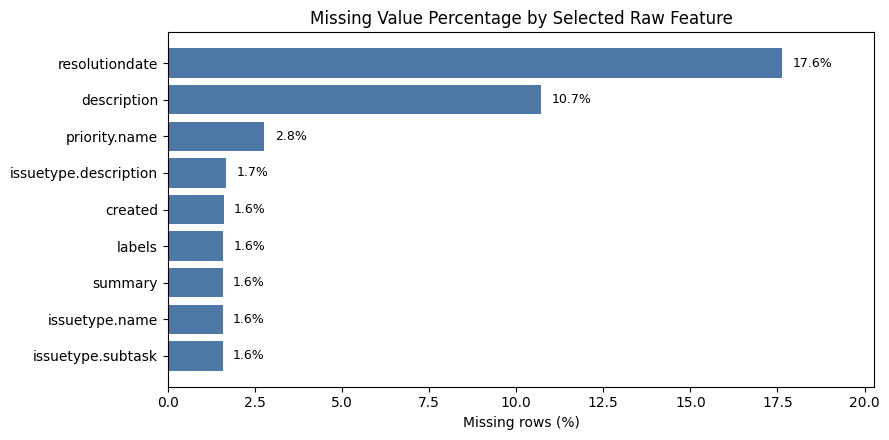

In [35]:
missing_table = pd.DataFrame({
    "missing_count": ticket_df.isna().sum(),
    "missing_percent": ticket_df.isna().mean() * 100
}).sort_values("missing_percent", ascending=True)

display(missing_table.sort_values("missing_percent", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(missing_table.index, missing_table["missing_percent"], color="#4E79A7")
ax.set_title("Missing Value Percentage by Selected Raw Feature")
ax.set_xlabel("Missing rows (%)")
ax.set_ylabel("")
ax.set_xlim(0, max(5, missing_table["missing_percent"].max() * 1.15))

for bar in bars:
    value = bar.get_width()
    if value > 0:
        ax.text(value + 0.3, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

**Rows with missing resolutiondate cannot be used for the first duration classification model because the target duration cannot be calculated.**

This chart highlights which selected raw features have the highest missing-value rates. A high missing percentage does not always mean a column is useless, but it does mean the cleaning notebook must handle that field deliberately.


#### 01-05 Timestamp quality checks

The timestamp checks stay simple and focus on three questions:

- Can **created** and **resolutiondate** be converted to datetime values?
- Are there extreme minimum or maximum dates that should be reviewed?
- Are there rows where **resolutiondate** happens before **created**?

In [ ]:
# Convert dates to datetime for EDA checks.
ticket_df["created"] = pd.to_datetime(
    ticket_df["created"],
    errors="coerce",
    utc=True,
)

ticket_df["resolutiondate"] = pd.to_datetime(
    ticket_df["resolutiondate"],
    errors="coerce",
    utc=True,
)

timestamp_quality = pd.DataFrame({
    "missing_or_invalid_count": ticket_df[["created", "resolutiondate"]].isna().sum(),
    "earliest_value": ticket_df[["created", "resolutiondate"]].min(),
    "latest_value": ticket_df[["created", "resolutiondate"]].max(),
})

display(timestamp_quality)

invalid_duration_count = (ticket_df["resolutiondate"] < ticket_df["created"]).sum()
print(f"Rows where resolutiondate is before created: {invalid_duration_count:,}")

#### 01-06 Duration target exploration

The main target feature is `duration_days`, calculated as:

`duration_days = resolutiondate - created`

This section inspects the raw numeric target before creating classes. The goal is to understand spread, missing values, negative values, and extreme values at a basic level.

In [36]:
eda_df = ticket_df.copy()
eda_df["duration_days"] = (eda_df["resolutiondate"] - eda_df["created"]).dt.total_seconds() / 86400

duration_summary = eda_df["duration_days"].describe()
display(duration_summary)

negative_duration_count = (eda_df["duration_days"] < 0).sum()
missing_duration_count = eda_df["duration_days"].isna().sum()
print(f"Missing duration rows: {missing_duration_count:,}")
print(f"Negative duration rows: {negative_duration_count:,}")

count    946426.000000
mean        203.954379
std         520.375742
min          -0.372951
25%           1.049771
50%          11.915307
75%         112.017925
max        8001.517257
Name: duration_days, dtype: float64

Missing duration rows: 202,897
Negative duration rows: 18


In [37]:
eda_df["duration_days"].quantile([
    0.00,
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.00,
])

0.00      -0.372951
0.01       0.000868
0.05       0.009699
0.10       0.059016
0.25       1.049771
0.50      11.915307
0.75     112.017925
0.90     623.853941
0.95    1199.511267
0.99    2694.205712
1.00    8001.517257
Name: duration_days, dtype: float64

#### 01-07 Duration class distribution

Create simple duration classes from `duration_days` and compare how many records fall into each group. These classes are exploratory and can be adjusted during cleaning or modeling.

duration_range
Very Quick    229378
Quick          90029
Standard       94631
Extended      121216
Long-range    403264
Name: task_count, dtype: int64

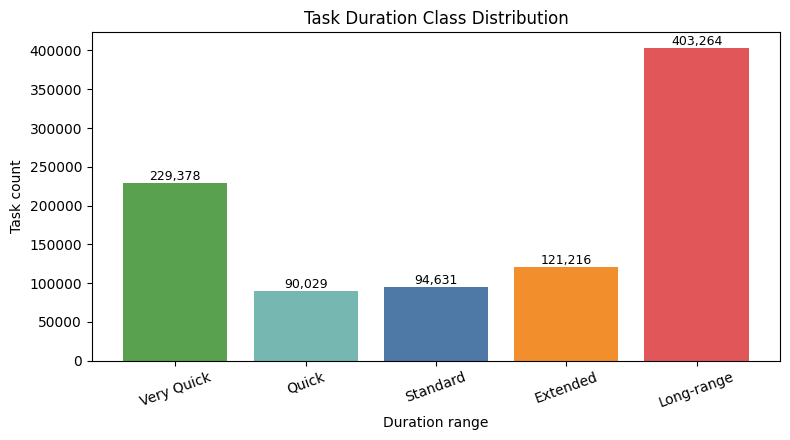

In [38]:
# Basic cleaning only for visualization in this EDA notebook.
# The formal cleaning steps are handled in 02-data-cleaning.ipynb.

cleaned_df = ticket_df.drop_duplicates()
cleaned_df = cleaned_df.dropna(subset=["created", "resolutiondate", "summary"]).copy()

cleaned_df["created"] = pd.to_datetime(cleaned_df["created"], errors="coerce", utc=True)
cleaned_df["resolutiondate"] = pd.to_datetime(cleaned_df["resolutiondate"], errors="coerce", utc=True)

cleaned_df["duration_days"] = (cleaned_df["resolutiondate"] - cleaned_df["created"]).dt.total_seconds() / (60 * 60 * 24)
cleaned_df = cleaned_df[cleaned_df["duration_days"].notna() & (cleaned_df["duration_days"] >= 0)]

def duration_range(days):
    if days <= 1:
        return "Very Quick"
    if days <= 3:
        return "Quick"
    if days <= 7:
        return "Standard"
    if days <= 21:
        return "Extended"
    return "Long-range"

duration_order = ["Very Quick", "Quick", "Standard", "Extended", "Long-range"]
cleaned_df["duration_range"] = cleaned_df["duration_days"].apply(duration_range)
duration_counts = cleaned_df["duration_range"].value_counts().reindex(duration_order)

display(duration_counts.rename("task_count"))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(duration_counts.index, duration_counts.values, color=["#59A14F", "#76B7B2", "#4E79A7", "#F28E2B", "#E15759"])
ax.set_title("Task Duration Class Distribution")
ax.set_xlabel("Duration range")
ax.set_ylabel("Task count")
ax.tick_params(axis="x", rotation=20)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

The class distribution shows whether the target is balanced or dominated by short or long tasks.

The next two simple plots inspect the shortest and longest duration ranges more closely because those ranges are likely to drive cleaning decisions.

##### Very Quick duration check

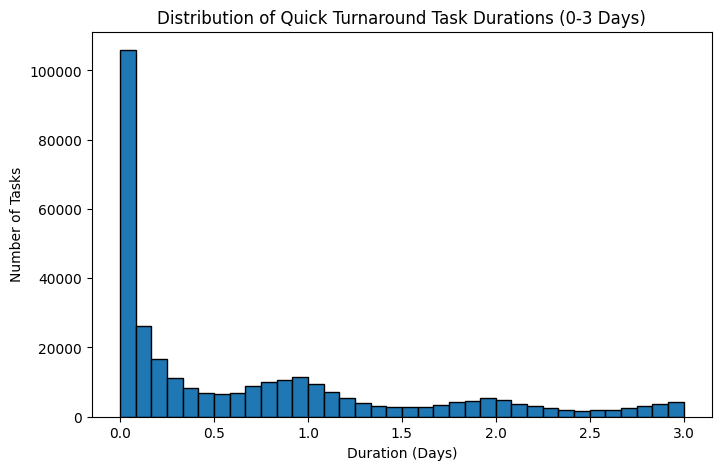

In [39]:
quick_df = cleaned_df[
    (cleaned_df["duration_days"] >= 0) &
    (cleaned_df["duration_days"] <= 3)
]

plt.figure(figsize=(8, 5))
plt.hist(quick_df["duration_days"], bins=36, edgecolor="black")
plt.title("Distribution of Quick Turnaround Task Durations (0-3 Days)")
plt.xlabel("Duration (Days)")
plt.ylabel("Number of Tasks")
plt.show()

The shortest tasks appear concentrated near the beginning of the range. The cleaning notebook should decide whether very short tasks are valid work items or need a separate class.

##### Long-range duration check

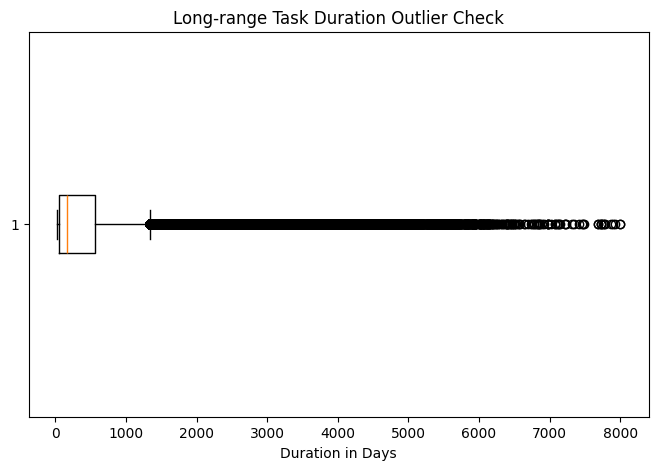

In [40]:
long_range_duration = cleaned_df.loc[
    cleaned_df["duration_days"] > 21,
    "duration_days",
].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot(long_range_duration, vert=False)
plt.title("Long-range Task Duration Outlier Check")
plt.xlabel("Duration in Days")
plt.show()

The long-range boxplot shows that some tickets remain open much longer than the typical long-range task. These values should be reviewed in cleaning before model training.

##### Class percentages

In [41]:
class_percentages = (
    cleaned_df["duration_range"]
    .value_counts(normalize=True)
    .reindex(duration_order)
    .mul(100)
    .round(2)
)

class_percentages

duration_range
Very Quick    24.44
Quick          9.59
Standard      10.08
Extended      12.92
Long-range    42.97
Name: proportion, dtype: float64

#### 01-08 Text feature exploration

Text fields are useful because task summaries and descriptions often contain signals about complexity. This section keeps the checks basic by looking at missing values, blank strings, and character lengths.

,feature,missing_count,blank_count,average_characters,median_characters,max_characters
0,summary,0,0,57.122085,54.0,255
1,description,92479,92576,1049.391875,325.0,8577458


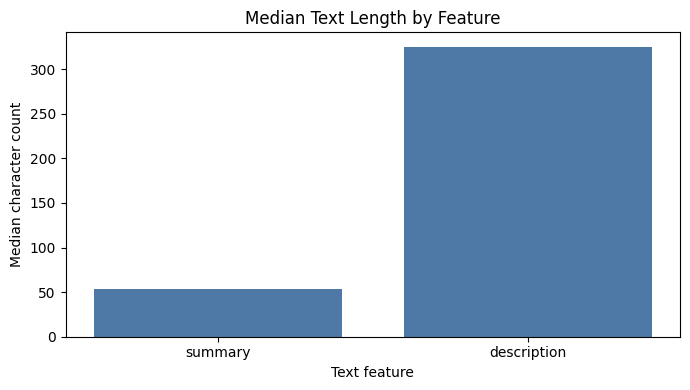

In [43]:
text_columns = ["summary", "description"]
text_summary = []

for column in text_columns:
    text_values = cleaned_df[column].astype("string")
    text_lengths = text_values.fillna("").str.len()
    blank_count = text_values.fillna("").str.strip().eq("").sum()

    text_summary.append({
        "feature": column,
        "missing_count": text_values.isna().sum(),
        "blank_count": blank_count,
        "average_characters": text_lengths.mean(),
        "median_characters": text_lengths.median(),
        "max_characters": text_lengths.max(),
    })

text_summary_df = pd.DataFrame(text_summary)
display(text_summary_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(text_summary_df["feature"], text_summary_df["median_characters"], color="#4E79A7")
ax.set_title("Median Text Length by Feature")
ax.set_xlabel("Text feature")
ax.set_ylabel("Median character count")
plt.tight_layout()
plt.show()

#### 01-09 Categorical feature exploration

Categorical fields help describe the type and priority of each task. The checks below look at unique value counts and the most frequent values so cleaning can decide whether rare categories should be grouped.

In [44]:
categorical_columns = ["priority.name", "issuetype.name", "issuetype.subtask"]

categorical_summary = pd.DataFrame({
    "feature": categorical_columns,
    "missing_count": [cleaned_df[column].isna().sum() for column in categorical_columns],
    "unique_count": [cleaned_df[column].nunique(dropna=True) for column in categorical_columns],
})

display(categorical_summary)

for column in categorical_columns:
    print(f"Top values for {column}")
    display(cleaned_df[column].value_counts(dropna=False).head(10))

,feature,missing_count,unique_count
0,priority.name,11846,15
1,issuetype.name,0,37
2,issuetype.subtask,0,2


Top values for priority.name


priority.name
Major       614994
Minor       177625
Critical     43868
Blocker      34508
Trivial      26931
NaN          11846
Normal       11188
P2            6388
Low           6160
P3            2629
Name: count, dtype: int64

Top values for issuetype.name


issuetype.name
Bug                   479382
Improvement           224438
Sub-task               87658
Task                   63720
New Feature            51239
Test                   10239
Dependency upgrade      7167
Wish                    5221
Documentation           2011
Question                2005
Name: count, dtype: int64

Top values for issuetype.subtask


issuetype.subtask
False    849823
True      88695
Name: count, dtype: int64

#### 01-10 Labels exploration

The **labels** field can contain no labels, one label, or multiple labels. This section checks how often labels are present and which labels appear most often.

Rows with no labels: 772,085
Rows with at least one label: 166,433


count    938518.000000
mean          0.177986
std           0.384801
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           7.000000
Name: labels, dtype: float64

labels
pull-request-available                   63892
ignite-3                                  3939
newbie                                    3526
bulk-closed                               3040
patch                                     2397
github-import                             1528
performance                                999
documentation                              996
ready-to-commit                            991
mesosphere                                 974
easyfix                                    881
features                                   877
test-stability                             857
pull-request-available test-stability      828
security                                   797
Name: count, dtype: int64

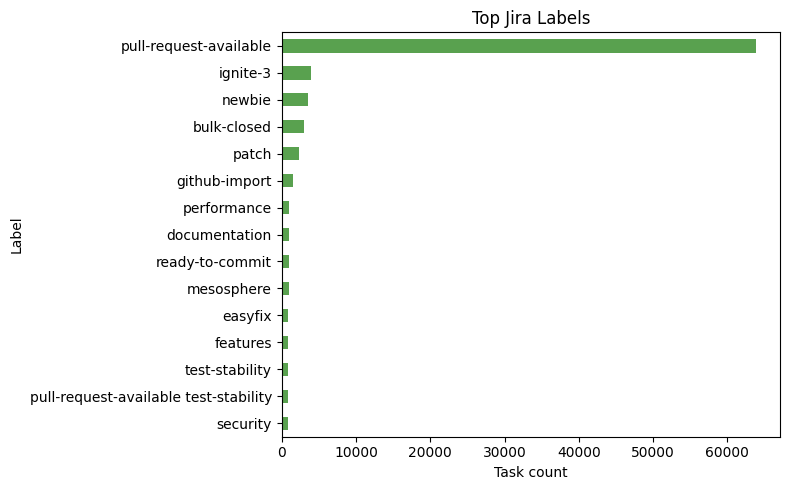

In [45]:
labels_text = cleaned_df["labels"].fillna("[]").astype(str)
empty_label_mask = labels_text.str.strip().isin(["[]", "", "nan", "None"])

label_count = labels_text.where(~empty_label_mask, "")
label_count = label_count.str.replace("[", "", regex=False)
label_count = label_count.str.replace("]", "", regex=False)
label_count = label_count.str.replace("'", "", regex=False)
label_count = label_count.str.strip()
label_count = label_count.apply(lambda value: 0 if value == "" else value.count(",") + 1)

print(f"Rows with no labels: {empty_label_mask.sum():,}")
print(f"Rows with at least one label: {(~empty_label_mask).sum():,}")
display(label_count.describe())

label_tokens = labels_text.where(~empty_label_mask).dropna()
label_tokens = label_tokens.str.replace("[", "", regex=False)
label_tokens = label_tokens.str.replace("]", "", regex=False)
label_tokens = label_tokens.str.replace("'", "", regex=False)
label_tokens = label_tokens.str.split(",").explode().str.strip()
label_tokens = label_tokens[label_tokens != ""]

top_labels = label_tokens.value_counts().head(15)
display(top_labels)

fig, ax = plt.subplots(figsize=(8, 5))
top_labels.sort_values().plot(kind="barh", ax=ax, color="#59A14F")
ax.set_title("Top Jira Labels")
ax.set_xlabel("Task count")
ax.set_ylabel("Label")
plt.tight_layout()
plt.show()

#### 01-11 EDA findings and cleaning decisions

Main findings from this EDA notebook:

- Keep the selected raw fields because they connect directly to the target or to simple model features.
- Drop rows that cannot produce the target, especially rows missing **created** or **resolutiondate**.
- Drop or review rows with invalid durations where **resolutiondate** is before **created**.
- Review very short durations separately because they may create a large short-task cluster.
- Review very long durations separately because they may represent stale or unusual tickets.
- Keep basic text-length features from **summary** and **description** after handling missing or blank text.
- Keep categorical fields such as priority and issue type, while grouping rare categories if needed later.
- Convert **labels** into simple count or top-label features after normalizing empty label values.

Cleaning notebook decisions to carry forward:

- Remove duplicate rows.
- Convert timestamp columns with errors="coerce" and handle invalid dates.
- Create duration_days only after timestamp checks.
- Remove negative or missing target durations before model training.
- Revisit the duration class cutoffs after checking class balance.